<a href="https://colab.research.google.com/github/kiana-whitney/you-can-run-you-can-hide-the-zombie-apocalypse-/blob/main/Model_Simulation_7_with_plotly_RR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


You will be prompted to authorize Google Drive access. Once mounted, the `read_csv_flexible` function will now search within `/content/drive/MyDrive/` for your CSV files, in addition to other locations.

In [ ]:
import pandas as pd
import re
from pathlib import Path


def read_csv_flexible(file_candidates, pattern_candidates=None):
    """Read a CSV by trying multiple base folders + exact names + wildcard patterns."""
    if isinstance(file_candidates, str):
        file_candidates = [file_candidates]
    pattern_candidates = pattern_candidates or []

    base_dirs = [
        Path.cwd(),
        Path.cwd() / "nc_data_cleaned",
        Path(r"C:\Users\rebec\Documents\BigData\Final Project\nc_data_cleaned"),
    ]

    # 1) Exact filename checks
    for base in base_dirs:
        for name in file_candidates:
            p = base / name
            if p.exists():
                print(f"Loaded: {p}")
                return pd.read_csv(p)

    # 2) Wildcard pattern checks
    for base in base_dirs:
        for pattern in pattern_candidates:
            matches = sorted(base.glob(pattern))
            if not matches:
                matches = sorted(base.rglob(pattern))
            if matches:
                print(f"Loaded (pattern match): {matches[0]}")
                return pd.read_csv(matches[0])

    searched = [str(base / name) for base in base_dirs for name in file_candidates]
    raise FileNotFoundError(
        "Could not find CSV. Tried exact paths:\n- " + "\n- ".join(searched) +
        (f"\nAlso tried patterns: {pattern_candidates}" if pattern_candidates else "")
    )


population = read_csv_flexible(
    ["nc_population_data.csv"],
    ["*population*.csv"]
)
geo = read_csv_flexible(
    ["nc_geography_and_weather.csv", "c_geography_and_weather.csv"],
    ["*geography*weather*.csv", "*geo*weather*.csv"]
)
health = read_csv_flexible(
    ["nc_health_and_physical_fitness.csv"],
    ["*health*physical*fitness*.csv", "*health*.csv"]
)
education = read_csv_flexible(
    ["nc_education.csv"],
    ["*education*.csv"]
)
mobility = read_csv_flexible(
    ["nc_mobility_and_escape.csv"],
    ["*mobility*escape*.csv", "*mobility*.csv"]
)
social = read_csv_flexible(
    ["nc_social_and_community.csv"],
    ["*social*community*.csv", "*social*.csv"]
)
prep = read_csv_flexible(
    ["nc_infrastructure_and_preparedness.csv"],
    ["*infrastructure*preparedness*.csv", "*preparedness*.csv"]
)
pop_density = read_csv_flexible(
    ["pop_density.csv"],
    ["*pop*density*.csv"]
)


def normalize_county_name(value):
    """Normalize county text to a stable join key across files."""
    if pd.isna(value):
        return None
    text = str(value).strip().upper()

    # Remove common state/county suffixes and punctuation that differ by source file.
    text = re.sub(r",?\s*NORTH\s+CAROLINA\b", "", text)
    text = re.sub(r"\bCOUNTY\b", "", text)
    text = re.sub(r"[^A-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text if text else None


def ensure_county_columns(df):
    """Ensure each dataframe has county and county_key columns.

    Supports files that already contain county_key (for example pop_density.csv).
    """
    out = df.copy()

    if "county_key" in out.columns:
        out["county_key"] = out["county_key"].map(normalize_county_name)
        if "county" not in out.columns:
            out["county"] = out["county_key"]
        return out

    # Detect whichever county column exists in each file.
    candidates = ["county", "County", "county_name", "CountyName", "County Name", "NAME", "County_Name"]
    county_col = next((c for c in candidates if c in out.columns), None)
    if county_col is None:
        raise ValueError(f"No county column found. Available columns: {list(out.columns)}")

    out["county"] = out[county_col].astype(str).str.strip()
    out["county_key"] = out["county"].map(normalize_county_name)
    return out


def drop_county_name_columns(df):
    # Keep only canonical county fields on merge output.
    to_drop = [c for c in ["County", "CountyName", "county_name", "County Name", "County_Name", "NAME"] if c in df.columns]
    return df.drop(columns=to_drop, errors="ignore")


# Standardize all source files
population = drop_county_name_columns(ensure_county_columns(population))
geo = drop_county_name_columns(ensure_county_columns(geo))
health = drop_county_name_columns(ensure_county_columns(health))
education = drop_county_name_columns(ensure_county_columns(education))
mobility = drop_county_name_columns(ensure_county_columns(mobility))
social = drop_county_name_columns(ensure_county_columns(social))
prep = drop_county_name_columns(ensure_county_columns(prep))
pop_density = drop_county_name_columns(ensure_county_columns(pop_density))

# Base frame from population to guarantee one row per county
base_cols = ["county", "county_key"] + [c for c in population.columns if c not in ["county", "county_key"]]
df = population[base_cols].copy()

# Merge each source and report matched counties safely
sources = [
    ("geo", geo),
    ("health", health),
    ("education", education),
    ("mobility", mobility),
    ("social", social),
    ("prep", prep),
    ("pop_density", pop_density),
]

for name, right_df in sources:
    right_clean = right_df.drop(columns=[c for c in ["county", "County", "CountyName", "county_name", "County Name", "County_Name", "NAME"] if c in right_df.columns], errors="ignore")

    before = len(df)
    merged = df.merge(right_clean, on="county_key", how="left", indicator=True)
    matched = int((merged["_merge"] == "both").sum())
    print(f"{name}: matched {matched}/{before} counties")

    df = merged.drop(columns=["_merge"])

print("\nFinal merged shape:", df.shape)
print("Counties with any missing values:", int(df.isna().any(axis=1).sum()))
print("\nExample dataframe columns:")
print(df.columns.tolist())
df.head()

Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_population_data.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_geogragraphy_and_weather.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_health_and_physical_fitness.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_education.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_mobility_and_escape.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_social_and_community.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_infrastructure_and_preparedness.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/pop_density.csv
geo: matched 57/100 counties
health: matched 100/100 counties
education: matched 100/100 counties
mobility: matched 100/100 counties
social: matched 101/100 counties
prep: matched 101/101 counties
pop_density: matched 101/101 counties

Final merged shape: (101, 56)
Counties with

,county,county_key,population,station_count,mean_survivability,median_survivability,mean_annual_precip,mean_elevation,survivability_category,county_fips_x,...,harvest_yield,permit_density,social_community_factors_score,county_fips,prepper_density,covid_compliance,grid_independence,score_I,infrastructure_category,safety_density_score
0,"Alamance County, North Carolina",ALAMANCE,176893,NaN,NaN,NaN,NaN,NaN,NaN,37001,...,0.511468,0.264145,0.183948,37001,37.421081,56.805676,16.128649,0.446474,Medium,0.852395
1,"Alexander County, North Carolina",ALEXANDER,36412,NaN,NaN,NaN,NaN,NaN,NaN,37003,...,0.196496,0.076163,0.037988,37003,38.035714,57.934286,16.432857,0.469887,Medium,0.971930
2,"Alleghany County, North Carolina",ALLEGHANY,11174,1.0,0.796404,0.796404,56.25,946.1,High,37005,...,0.421347,0.019454,0.023681,37005,31.176667,56.510000,17.656667,0.346273,Low,0.993405
3,"Anson County, North Carolina",ANSON,22289,NaN,NaN,NaN,NaN,NaN,NaN,37007,...,0.806032,0.036049,0.052034,37007,39.264444,57.268889,15.204444,0.475361,Medium,0.983947
4,"Ashe County, North Carolina",ASHE,26950,NaN,NaN,NaN,NaN,NaN,NaN,37009,...,0.460177,0.066436,0.043387,37009,33.468889,56.268889,15.601111,0.367307,Low,0.979981


In [ ]:
import pandas as pd
import re
from pathlib import Path


def read_csv_flexible(file_candidates, pattern_candidates=None):
    """Read a CSV by trying multiple base folders + exact names + wildcard patterns."""
    if isinstance(file_candidates, str):
        file_candidates = [file_candidates]
    pattern_candidates = pattern_candidates or []

    base_dirs = [
        Path.cwd(),
        Path.cwd() / "nc_data_cleaned",
        # Add Google Drive paths
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/nc_data_cleaned"),
        Path(r"C:\Users\rebec\Documents\BigData\Final Project\nc_data_cleaned"), # Keep for local testing if needed
    ]

    # 1) Exact filename checks
    for base in base_dirs:
        for name in file_candidates:
            p = base / name
            if p.exists():
                print(f"Loaded: {p}")
                return pd.read_csv(p)

    # 2) Wildcard pattern checks
    for base in base_dirs:
        for pattern in pattern_candidates:
            matches = sorted(base.glob(pattern))
            if not matches:
                matches = sorted(base.rglob(pattern))
            if matches:
                print(f"Loaded (pattern match): {matches[0]}")
                return pd.read_csv(matches[0])

    searched = [str(base / name) for base in base_dirs for name in file_candidates]
    raise FileNotFoundError(
        "Could not find CSV. Tried exact paths:\n- " + "\n- ".join(searched) +
        (f"\nAlso tried patterns: {pattern_candidates}" if pattern_candidates else "")
    )


population = read_csv_flexible(
    ["nc_population_data.csv"],
    ["*population*.csv"]
)
geo = read_csv_flexible(
    ["nc_geography_and_weather.csv", "c_geography_and_weather.csv"],
    ["*geography*weather*.csv", "*geo*weather*.csv"]
)
health = read_csv_flexible(
    ["nc_health_and_physical_fitness.csv"],
    ["*health*physical*fitness*.csv", "*health*.csv"]
)
education = read_csv_flexible(
    ["nc_education.csv"],
    ["*education*.csv"]
)
mobility = read_csv_flexible(
    ["nc_mobility_and_escape.csv"],
    ["*mobility*escape*.csv", "*mobility*.csv"]
)
social = read_csv_flexible(
    ["nc_social_and_community.csv"],
    ["*social*community*.csv", "*social*.csv"]
)
prep = read_csv_flexible(
    ["nc_infrastructure_and_preparedness.csv"],
    ["*infrastructure*preparedness*.csv", "*preparedness*.csv"]
)
pop_density = read_csv_flexible(
    ["pop_density.csv"],
    ["*pop*density*.csv"]
)


def normalize_county_name(value):
    """Normalize county text to a stable join key across files."""
    if pd.isna(value):
        return None
    text = str(value).strip().upper()

    # Remove common state/county suffixes and punctuation that differ by source file.
    text = re.sub(r",?\s*NORTH\s+CAROLINA\b", "", text)
    text = re.sub(r"\bCOUNTY\b", "", text)
    text = re.sub(r"[^A-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text if text else None


def ensure_county_columns(df):
    """Ensure each dataframe has county and county_key columns.

    Supports files that already contain county_key (for example pop_density.csv).
    """
    out = df.copy()

    if "county_key" in out.columns:
        out["county_key"] = out["county_key"].map(normalize_county_name)
        if "county" not in out.columns:
            out["county"] = out["county_key"]
        return out

    # Detect whichever county column exists in each file.
    candidates = ["county", "County", "county_name", "CountyName", "County Name", "NAME", "County_Name"]
    county_col = next((c for c in candidates if c in out.columns), None)
    if county_col is None:
        raise ValueError(f"No county column found. Available columns: {list(out.columns)}")

    out["county"] = out[county_col].astype(str).str.strip()
    out["county_key"] = out["county"].map(normalize_county_name)
    return out


def drop_county_name_columns(df):
    # Keep only canonical county fields on merge output.
    to_drop = [c for c in ["County", "CountyName", "county_name", "County Name", "County_Name", "NAME"] if c in df.columns]
    return df.drop(columns=to_drop, errors="ignore")


# Standardize all source files
population = drop_county_name_columns(ensure_county_columns(population))
geo = drop_county_name_columns(ensure_county_columns(geo))
health = drop_county_name_columns(ensure_county_columns(health))
education = drop_county_name_columns(ensure_county_columns(education))
mobility = drop_county_name_columns(ensure_county_columns(mobility))
social = drop_county_name_columns(ensure_county_columns(social))
prep = drop_county_name_columns(ensure_county_columns(prep))
pop_density = drop_county_name_columns(ensure_county_columns(pop_density))

# Base frame from population to guarantee one row per county
base_cols = ["county", "county_key"] + [c for c in population.columns if c not in ["county", "county_key"]]
df = population[base_cols].copy()

# Merge each source and report matched counties safely
sources = [
    ("geo", geo),
    ("health", health),
    ("education", education),
    ("mobility", mobility),
    ("social", social),
    ("prep", prep),
    ("pop_density", pop_density),
]

for name, right_df in sources:
    right_clean = right_df.drop(columns=[c for c in ["county", "County", "CountyName", "county_name", "County Name", "County_Name", "NAME"] if c in right_df.columns], errors="ignore")

    before = len(df)
    merged = df.merge(right_clean, on="county_key", how="left", indicator=True)
    matched = int((merged["_merge"] == "both").sum())
    print(f"{name}: matched {matched}/{before} counties")

    df = merged.drop(columns=["_merge"])

print("\nFinal merged shape:", df.shape)
print("Counties with any missing values:", int(df.isna().any(axis=1).sum()))
print("\nExample dataframe columns:")
print(df.columns.tolist())
df.head()


Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_population_data.csv
Loaded (pattern match): /content/drive/MyDrive/nc_data_cleaned/nc_geogragraphy_and_weather.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_health_and_physical_fitness.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_education.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_mobility_and_escape.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_social_and_community.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/nc_infrastructure_and_preparedness.csv
Loaded: /content/drive/MyDrive/nc_data_cleaned/pop_density.csv
geo: matched 57/100 counties
health: matched 100/100 counties
education: matched 100/100 counties
mobility: matched 100/100 counties
social: matched 101/100 counties
prep: matched 101/101 counties
pop_density: matched 101/101 counties

Final merged shape: (101, 56)
Counties with any missing values: 45

Example dataframe columns:
['county', 'county_key', 'population', 'station_count', 'mea

,county,county_key,population,station_count,mean_survivability,median_survivability,mean_annual_precip,mean_elevation,survivability_category,county_fips_x,...,harvest_yield,permit_density,social_community_factors_score,county_fips,prepper_density,covid_compliance,grid_independence,score_I,infrastructure_category,safety_density_score
0,"Alamance County, North Carolina",ALAMANCE,176893,NaN,NaN,NaN,NaN,NaN,NaN,37001,...,0.511468,0.264145,0.183948,37001,37.421081,56.805676,16.128649,0.446474,Medium,0.852395
1,"Alexander County, North Carolina",ALEXANDER,36412,NaN,NaN,NaN,NaN,NaN,NaN,37003,...,0.196496,0.076163,0.037988,37003,38.035714,57.934286,16.432857,0.469887,Medium,0.971930
2,"Alleghany County, North Carolina",ALLEGHANY,11174,1.0,0.796404,0.796404,56.25,946.1,High,37005,...,0.421347,0.019454,0.023681,37005,31.176667,56.510000,17.656667,0.346273,Low,0.993405
3,"Anson County, North Carolina",ANSON,22289,NaN,NaN,NaN,NaN,NaN,NaN,37007,...,0.806032,0.036049,0.052034,37007,39.264444,57.268889,15.204444,0.475361,Medium,0.983947
4,"Ashe County, North Carolina",ASHE,26950,NaN,NaN,NaN,NaN,NaN,NaN,37009,...,0.460177,0.066436,0.043387,37009,33.468889,56.268889,15.601111,0.367307,Low,0.979981


In [ ]:
# Keep a stable modeling subset whether columns are pre-rename or post-rename.
column_aliases = {
    "county_key": ["county_key"],
    "population": ["population"],
    "geo_score": ["mean_survivability", "geo_score"],
    "health_score": ["score_H", "health_score"],
    "edu_score": ["education_score_normalized", "edu_score"],
    "mobility_score": ["score_M", "mobility_score"],
    "social_score": ["social_community_factors_score", "social_score"],
    "prep_score": ["score_I", "prep_score"],
    "safety_density_score": ["safety_density_score"],
}

selected = pd.DataFrame(index=df.index)
missing_required = []

for target, candidates in column_aliases.items():
    source = next((c for c in candidates if c in df.columns), None)
    if source is None:
        if target == "safety_density_score":
            # Optional in case pop density file is not merged yet.
            selected[target] = pd.NA
        else:
            missing_required.append(target)
    else:
        selected[target] = df[source]

if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}. Available: {list(df.columns)}")

df = selected
display(df.head())

,county_key,population,geo_score,health_score,edu_score,mobility_score,social_score,prep_score,safety_density_score
0,ALAMANCE,176893,NaN,0.673412,0.403077,0.968961,0.183948,0.446474,0.852395
1,ALEXANDER,36412,NaN,0.784297,0.169231,0.977808,0.037988,0.469887,0.971930
2,ALLEGHANY,11174,0.796404,0.681099,0.244615,0.929099,0.023681,0.346273,0.993405
3,ANSON,22289,NaN,0.665258,0.050769,0.948131,0.052034,0.475361,0.983947
4,ASHE,26950,NaN,0.674779,0.306154,0.956762,0.043387,0.367307,0.979981


Rows in model_df: 100
Unique counties in model_df: 100
Rows in summary_df: 100
Unique counties in summary_df: 100

Growth-rate summary:
count    100.000000
mean       0.023223
std        0.003347
min        0.008500
25%        0.022000
50%        0.023285
75%        0.025377
max        0.030000
Name: growth_rate, dtype: float64

Counties where zombies should grow:
100

Top 10 counties by final survival fraction:


,county_key,survival_fraction,final_zombies,peak_zombies,peak_day
91,wake,0.999893,21.326042,21.326042,360.0
59,mecklenburg,0.999786,50.188924,50.188924,360.0
10,buncombe,0.995264,362.006105,362.006105,360.0
40,guilford,0.994353,968.089525,968.089525,360.0
31,durham,0.990776,958.456813,958.456813,360.0
33,forsyth,0.989010,1393.494829,1393.494829,360.0
89,union,0.988942,857.353811,857.353811,360.0
12,cabarrus,0.987664,905.446947,905.446947,360.0
67,orange,0.987315,558.696181,558.696181,360.0
48,iredell,0.980923,1201.870472,1201.870472,360.0



Bottom 10 counties by final survival fraction:


,county_key,survival_fraction,final_zombies,peak_zombies,peak_day
88,tyrrell,0.071431,1276.400941,1276.400941,360.0
93,washington,0.086037,4235.613579,4235.613579,360.0
51,jones,0.093683,3556.494540,3556.494540,360.0
47,hyde,0.125266,1573.363073,1573.363073,360.0
36,gates,0.220734,3200.018348,3200.018348,360.0
92,warren,0.244805,5809.321492,5809.321492,360.0
71,perquimans,0.248705,3964.151863,3964.151863,360.0
58,martin,0.271502,6454.079165,6454.079165,360.0
65,northampton,0.286030,4835.307008,4835.307008,360.0
68,pamlico,0.302209,3356.666178,3356.666178,360.0



Checkpoint results:


,county_key,day,survival_fraction,zombies,zombie_fraction
352,tyrrell,90.0,0.992095,11.459437,0.003348
188,hyde,90.0,0.994489,10.517024,0.002290
204,jones,90.0,0.996606,13.896351,0.001494
372,washington,90.0,0.996922,14.833772,0.001372
144,gates,90.0,0.997483,10.937768,0.001054
...,...,...,...,...,...
127,durham,360.0,0.990776,958.456813,0.002884
163,guilford,360.0,0.994353,968.089525,0.001767
43,buncombe,360.0,0.995264,362.006105,0.001319
239,mecklenburg,360.0,0.999786,50.188924,0.000043



County checkpoint table:


,county_key,survival_day_90,survival_day_180,survival_day_270,survival_day_360,zombies_day_90,zombies_day_180,zombies_day_270,zombies_day_360,zombie_fraction_day_90,zombie_fraction_day_180,zombie_fraction_day_270,zombie_fraction_day_360
0,alamance,0.999890,0.999106,0.993268,0.951590,7.497592,56.114606,418.432810,3004.987106,0.000042,0.000317,0.002365,0.016988
1,alexander,0.999398,0.994410,0.952920,0.698051,8.729753,75.819745,633.916576,4062.198749,0.000240,0.002082,0.017410,0.111562
2,alleghany,0.998227,0.985526,0.897930,0.533652,7.649644,57.816573,403.805899,1842.643477,0.000685,0.005174,0.036138,0.164905
3,anson,0.998882,0.987947,0.887775,0.432869,10.300875,105.053755,973.074227,4914.976008,0.000462,0.004713,0.043657,0.220511
4,ashe,0.999267,0.993992,0.955501,0.737520,7.623645,57.794000,423.935342,2497.448262,0.000283,0.002144,0.015730,0.092670
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,wayne,0.999812,0.998222,0.984300,0.875558,8.897945,79.011261,692.949285,5488.095733,0.000075,0.000666,0.005840,0.046254
96,wilkes,0.999694,0.997417,0.979901,0.861227,7.844584,61.350733,473.003698,3262.119500,0.000119,0.000930,0.007174,0.049475
97,wilson,0.999706,0.997064,0.972829,0.791111,9.432948,88.738199,816.123994,6270.181612,0.000119,0.001119,0.010293,0.079079
98,yadkin,0.999398,0.994198,0.949332,0.672646,9.090072,82.205315,713.055798,4603.463352,0.000242,0.002188,0.018977,0.122517



Statewide averages every 3 months:


,day,survival_fraction,zombie_fraction
0,90.0,0.999230,0.000314
1,180.0,0.992056,0.003092
2,270.0,0.934654,0.025412
3,360.0,0.716702,0.108475


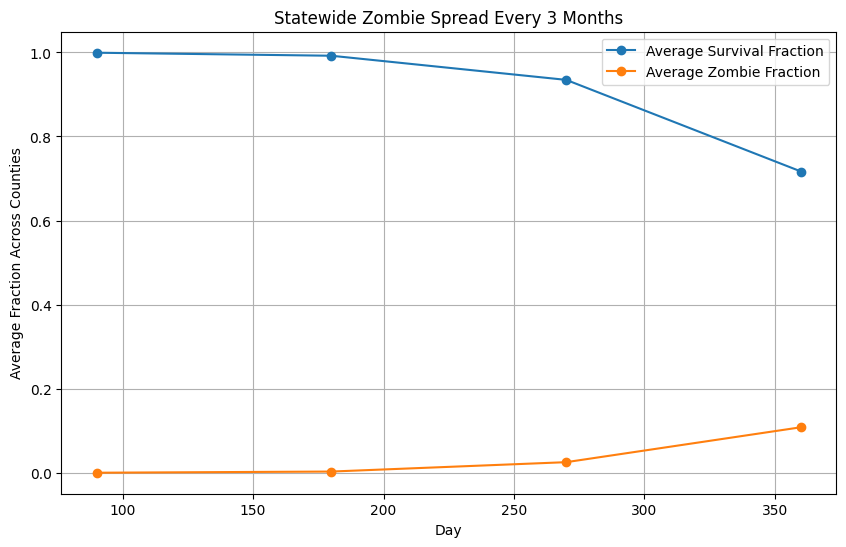

In [ ]:
# =========================================================
# ALL-IN-ONE ZOMBIE MODEL CELL
# Copy and paste this as ONE cell under your data-loading code
#
# Assumes your existing dataframe is named: df
# And df already contains these columns:
#   county_key, population,
#   geo_score, health_score, edu_score,
#   mobility_score, social_score, prep_score
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# -----------------------------
# NC county name -> FIPS
# -----------------------------
nc_fips = {
    "alamance": "37001", "alexander": "37003", "alleghany": "37005", "anson": "37007",
    "ashe": "37009", "avery": "37011", "beaufort": "37013", "bertie": "37015",
    "bladen": "37017", "brunswick": "37019", "buncombe": "37021", "burke": "37023",
    "cabarrus": "37025", "caldwell": "37027", "camden": "37029", "carteret": "37031",
    "caswell": "37033", "catawba": "37035", "chatham": "37037", "cherokee": "37039",
    "chowan": "37041", "clay": "37043", "cleveland": "37045", "columbus": "37047",
    "craven": "37049", "cumberland": "37051", "currituck": "37053", "dare": "37055",
    "davidson": "37057", "davie": "37059", "duplin": "37061", "durham": "37063",
    "edgecombe": "37065", "forsyth": "37067", "franklin": "37069", "gaston": "37071",
    "gates": "37073", "graham": "37075", "granville": "37077", "greene": "37079",
    "guilford": "37081", "halifax": "37083", "harnett": "37085", "haywood": "37087",
    "henderson": "37089", "hertford": "37091", "hoke": "37093", "hyde": "37095",
    "iredell": "37097", "jackson": "37099", "johnston": "37101", "jones": "37103",
    "lee": "37105", "lenoir": "37107", "lincoln": "37109", "macon": "37113",
    "madison": "37115", "martin": "37117", "mcdowell": "37111", "mecklenburg": "37119",
    "mitchell": "37121", "montgomery": "37123", "moore": "37125", "nash": "37127",
    "new hanover": "37129", "northampton": "37131", "onslow": "37133", "orange": "37135",
    "pamlico": "37137", "pasquotank": "37139", "pender": "37141", "perquimans": "37143",
    "person": "37145", "pitt": "37147", "polk": "37149", "randolph": "37151",
    "richmond": "37153", "robeson": "37155", "rockingham": "37157", "rowan": "37159",
    "rutherford": "37161", "sampson": "37163", "scotland": "37165", "stanly": "37167",
    "stokes": "37169", "surry": "37171", "swain": "37173", "transylvania": "37175",
    "tyrrell": "37177", "union": "37179", "vance": "37181", "wake": "37183",
    "warren": "37185", "washington": "37187", "watauga": "37189", "wayne": "37191",
    "wilkes": "37193", "wilson": "37195", "yadkin": "37197", "yancey": "37199"
}

# -----------------------------
# 1. Region assignment
# -----------------------------
MOUNTAIN_COUNTIES = {
    "ALLEGHANY", "ASHE", "AVERY", "BUNCOMBE", "BURKE", "CALDWELL", "CHEROKEE", "CLAY",
    "GRAHAM", "HAYWOOD", "HENDERSON", "JACKSON", "MACON", "MADISON", "MCDOWELL",
    "MITCHELL", "SWAIN", "TRANSYLVANIA", "WATAUGA", "WILKES", "YANCEY"
}

COASTAL_COUNTIES = {
    "BEAUFORT", "BERTIE", "BLADEN", "BRUNSWICK", "CAMDEN", "CARTERET", "CHOWAN",
    "COLUMBUS", "CRAVEN", "CURRITUCK", "DARE", "DUPLIN", "EDGECOMBE", "GATES",
    "GREENE", "HALIFAX", "HERTFORD", "HYDE", "JONES", "LENOIR", "MARTIN", "NASH",
    "NEW HANOVER", "NORTHAMPTON", "ONSLOW", "PAMLICO", "PASQUOTANK", "PENDER",
    "PERQUIMANS", "PITT", "ROBESON", "SAMPSON", "TYRRELL", "WASHINGTON", "WAYNE",
    "WILSON"
}

def assign_region(df):
    out = df.copy()
    county_upper = out["county_key"].astype(str).str.upper().str.strip()

    out["region"] = np.select(
        [
            county_upper.isin(COASTAL_COUNTIES),
            county_upper.isin(MOUNTAIN_COUNTIES)
        ],
        [
            "coastal",
            "mountain"
        ],
        default="central"
    )
    return out

# -----------------------------
# 2. Clean + fill missing scores
# -----------------------------
def clean_model_df(df):
    out = df.copy()

    required_cols = [
        "county_key", "population",
        "geo_score", "health_score", "edu_score",
        "mobility_score", "social_score", "prep_score"
    ]
    missing = [col for col in required_cols if col not in out.columns]
    if missing:
        raise ValueError(f"Missing required columns in df: {missing}")

    out["county_key"] = out["county_key"].astype(str).str.strip().str.lower()
    out["population"] = pd.to_numeric(out["population"], errors="coerce")

    score_cols = [
        "geo_score", "health_score", "edu_score",
        "mobility_score", "social_score", "prep_score"
    ]

    for col in score_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = assign_region(out)

    for col in score_cols:
        out[col] = out.groupby("region")[col].transform(lambda s: s.fillna(s.mean()))
        out[col] = out[col].fillna(out[col].mean())

    out = out.drop_duplicates(subset="county_key", keep="first").copy()
    out = out.dropna(subset=["county_key", "population"]).copy()

    return out

# -----------------------------
# 3. Survivability index
# -----------------------------
def compute_survivability_index(df):
    out = df.copy()

    out["survivability_raw"] = (
        0.15 * out["geo_score"] +
        0.20 * out["health_score"] +
        0.10 * out["edu_score"] +
        0.15 * out["mobility_score"] +
        0.25 * out["social_score"] +
        0.15 * out["prep_score"]
    )

    min_val = out["survivability_raw"].min()
    max_val = out["survivability_raw"].max()

    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        out["survivability_index"] = 0.5
    else:
        out["survivability_index"] = (
            (out["survivability_raw"] - min_val) / (max_val - min_val)
        )

    return out

# -----------------------------
# 4. Convert survivability into beta and kappa
# Tuned so zombies actually grow faster
# -----------------------------
def compute_parameters(df, beta0=0.06, kappa0=0.04, a=0.25, b=0.10):
    out = df.copy()

    out["beta"] = beta0 * (1 - a * out["survivability_index"])
    out["kappa"] = kappa0 * (1 + b * out["survivability_index"])

    # Controlled clipping
    out["beta"] = out["beta"].clip(lower=beta0 * 0.6, upper=beta0 * 1.1)
    out["kappa"] = out["kappa"].clip(lower=kappa0 * 0.8, upper=kappa0 * 1.3)

    out["growth_rate"] = out["beta"] - out["kappa"]

    return out

# -----------------------------
# 5. SZR model
# Frequency-dependent transmission
# -----------------------------
def szr_model(t, y, beta, kappa, N):
    S, Z, R = y

    infection = beta * S * Z / N
    removal = kappa * S * Z / N

    dSdt = -infection
    dZdt = infection - removal
    dRdt = removal

    return [dSdt, dZdt, dRdt]

# -----------------------------
# 6. Simulate one county
# -----------------------------
def simulate_county(population, beta, kappa, z0=1, days=360):
    if pd.isna(population) or population <= 1:
        return None

    population = float(population)
    z0 = min(float(z0), population - 1)

    S0 = population - z0
    Z0 = z0
    R0 = 0.0

    # Daily output for a full year
    t_eval = np.arange(0, days + 1)

    sol = solve_ivp(
        fun=lambda t, y: szr_model(t, y, beta=float(beta), kappa=float(kappa), N=population),
        t_span=(0, float(days)),
        y0=[S0, Z0, R0],
        t_eval=t_eval,
        vectorized=False
    )

    return sol

# -----------------------------
# 7. Run simulations for all counties
# Returns:
#   summary_df    -> one row per county
#   timeseries_df -> one row per county per day
# -----------------------------
def run_simulations(df, days=360, z0=1):
    summary_results = []
    timeseries_results = []

    for _, row in df.iterrows():
        population = row["population"]
        beta = row["beta"]
        kappa = row["kappa"]

        if pd.isna(population) or pd.isna(beta) or pd.isna(kappa):
            continue

        sol = simulate_county(
            population=population,
            beta=beta,
            kappa=kappa,
            z0=z0,
            days=days
        )

        if sol is None or not sol.success:
            continue

        S = sol.y[0]
        Z = sol.y[1]
        R = sol.y[2]
        t = sol.t
        population = float(population)

        summary_results.append({
            "county_key": row["county_key"],
            "region": row["region"],
            "population": population,
            "survivability_index": row["survivability_index"],
            "beta": beta,
            "kappa": kappa,
            "growth_rate": row["growth_rate"],
            "survival_fraction": S[-1] / population,
            "final_susceptible": S[-1],
            "final_zombies": Z[-1],
            "final_removed": R[-1],
            "peak_zombies": float(Z.max()),
            "peak_day": float(t[Z.argmax()])
        })

        for i in range(len(t)):
            timeseries_results.append({
                "county_key": row["county_key"],
                "region": row["region"],
                "day": float(t[i]),
                "susceptible": float(S[i]),
                "zombies": float(Z[i]),
                "removed": float(R[i]),
                "survival_fraction": float(S[i] / population),
                "zombie_fraction": float(Z[i] / population),
                "removed_fraction": float(R[i] / population)
            })

    return pd.DataFrame(summary_results), pd.DataFrame(timeseries_results)

# -----------------------------
# 8. Build model dataframe
# -----------------------------
model_df = clean_model_df(df)
model_df = compute_survivability_index(model_df)
model_df = compute_parameters(model_df, beta0=0.07, kappa0=0.04, a=0.25, b=0.10)
model_df["fips"] = model_df["county_key"].map(nc_fips)

missing_fips = model_df[model_df["fips"].isna()]["county_key"].unique().tolist()
if missing_fips:
    print("These counties did not match the FIPS lookup:")
    print(missing_fips)

model_df = model_df.dropna(subset=["fips"]).copy()
model_df["fips"] = model_df["fips"].astype(str).str.zfill(5)

# -----------------------------
# 9. Run 1-year simulation
# -----------------------------
summary_df, timeseries_df = run_simulations(model_df, days=360, z0=1)

# -----------------------------
# 10. Pull checkpoints every 3 months
# -----------------------------
checkpoints = [90, 180, 270, 360]
checkpoint_rows = []

for county in timeseries_df["county_key"].unique():
    county_data = timeseries_df[timeseries_df["county_key"] == county]

    for cp in checkpoints:
        idx = (county_data["day"] - cp).abs().idxmin()
        checkpoint_rows.append(county_data.loc[idx])

checkpoint_df = pd.DataFrame(checkpoint_rows).reset_index(drop=True)

# -----------------------------
# 11. Make county checkpoint tables
# -----------------------------
survival_table = checkpoint_df.pivot(
    index="county_key",
    columns="day",
    values="survival_fraction"
)
survival_table.columns = [f"survival_day_{int(c)}" for c in survival_table.columns]

zombie_table = checkpoint_df.pivot(
    index="county_key",
    columns="day",
    values="zombies"
)
zombie_table.columns = [f"zombies_day_{int(c)}" for c in zombie_table.columns]

zombie_fraction_table = checkpoint_df.pivot(
    index="county_key",
    columns="day",
    values="zombie_fraction"
)
zombie_fraction_table.columns = [f"zombie_fraction_day_{int(c)}" for c in zombie_fraction_table.columns]

county_checkpoint_table = (
    survival_table
    .join(zombie_table)
    .join(zombie_fraction_table)
    .reset_index()
)

# -----------------------------
# 12. Statewide averages at 3-month checkpoints
# -----------------------------
statewide_df = (
    checkpoint_df.groupby("day")[["survival_fraction", "zombie_fraction"]]
    .mean()
    .reset_index()
)

# -----------------------------
# 13. Output checks
# -----------------------------
print("Rows in model_df:", len(model_df))
print("Unique counties in model_df:", model_df["county_key"].nunique())
print("Rows in summary_df:", len(summary_df))
print("Unique counties in summary_df:", summary_df["county_key"].nunique())

print("\nGrowth-rate summary:")
print(model_df["growth_rate"].describe())

print("\nCounties where zombies should grow:")
print((model_df["growth_rate"] > 0).sum())

print("\nTop 10 counties by final survival fraction:")
display(
    summary_df.sort_values("survival_fraction", ascending=False)[
        ["county_key", "survival_fraction", "final_zombies", "peak_zombies", "peak_day"]
    ].head(10)
)

print("\nBottom 10 counties by final survival fraction:")
display(
    summary_df.sort_values("survival_fraction", ascending=True)[
        ["county_key", "survival_fraction", "final_zombies", "peak_zombies", "peak_day"]
    ].head(10)
)

print("\nCheckpoint results:")
display(
    checkpoint_df[
        ["county_key", "day", "survival_fraction", "zombies", "zombie_fraction"]
    ].sort_values(["day", "zombie_fraction"], ascending=[True, False])
)

print("\nCounty checkpoint table:")
display(county_checkpoint_table)

print("\nStatewide averages every 3 months:")
display(statewide_df)

# -----------------------------
# 14. Plot statewide averages
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(
    statewide_df["day"],
    statewide_df["survival_fraction"],
    marker="o",
    label="Average Survival Fraction"
)
plt.plot(
    statewide_df["day"],
    statewide_df["zombie_fraction"],
    marker="o",
    label="Average Zombie Fraction"
)
plt.xlabel("Day")
plt.ylabel("Average Fraction Across Counties")
plt.title("Statewide Zombie Spread Every 3 Months")
plt.legend()
plt.grid(True)
plt.show()

Statewide averages every 30 days:


,day,survival_fraction,zombie_fraction
0,0,0.999967,0.000033
1,30,0.999871,0.000069
2,60,0.999667,0.000147
3,90,0.999230,0.000314
4,120,0.998296,0.000674
5,150,0.996297,0.001446
6,180,0.992056,0.003092
7,210,0.983269,0.006511
8,240,0.965970,0.013248
9,270,0.934654,0.025412


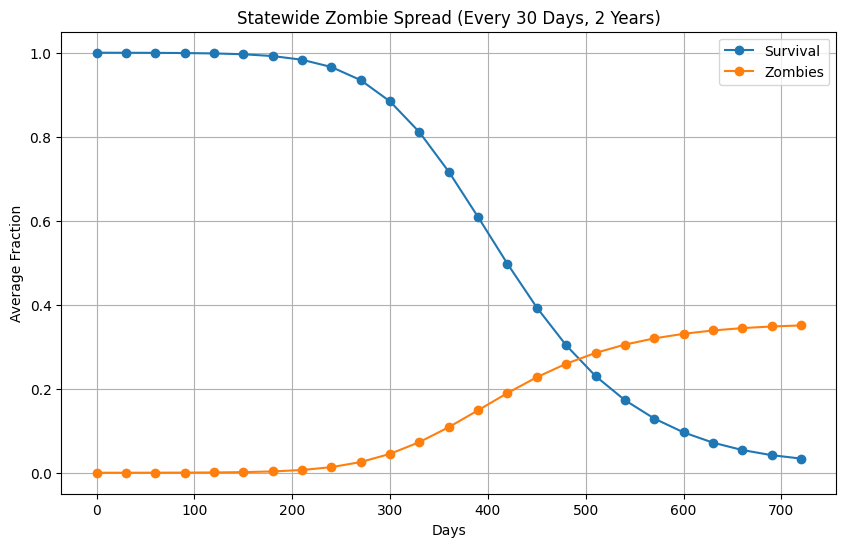


Zombie fraction by county (every 30 days):


,day_0,day_30,day_60,day_90,day_120,day_150,day_180,day_210,day_240,day_270,...,day_450,day_480,day_510,day_540,day_570,day_600,day_630,day_660,day_690,day_720
county_key,,,,,,,,,,,,,,,,,,,,,
alamance,0.000006,0.000011,0.000022,0.000042,0.000083,0.000162,0.000317,0.000621,0.001212,0.002365,...,0.096925,0.150243,0.208561,0.260142,0.297843,0.321607,0.335281,0.342711,0.346636,0.348676
alexander,0.000027,0.000057,0.000116,0.000240,0.000493,0.001014,0.002082,0.004262,0.008671,0.017410,...,0.292335,0.327518,0.347823,0.358612,0.364104,0.366823,0.368159,0.368813,0.369132,0.369286
alleghany,0.000089,0.000176,0.000348,0.000685,0.001346,0.002645,0.005174,0.010059,0.019293,0.036138,...,0.307631,0.328667,0.340474,0.346786,0.350086,0.351778,0.352644,0.353086,0.353311,0.353424
anson,0.000045,0.000098,0.000212,0.000462,0.001005,0.002179,0.004713,0.010107,0.021353,0.043657,...,0.362039,0.376033,0.382828,0.386028,0.387520,0.388210,0.388527,0.388673,0.388741,0.388772
ashe,0.000037,0.000073,0.000144,0.000283,0.000556,0.001094,0.002144,0.004199,0.008166,0.015730,...,0.258197,0.297585,0.322501,0.336814,0.344580,0.348670,0.350777,0.351860,0.352414,0.352695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wayne,0.000008,0.000017,0.000036,0.000075,0.000155,0.000322,0.000666,0.001377,0.002842,0.005840,...,0.207935,0.269274,0.314122,0.341487,0.356461,0.364159,0.367999,0.369880,0.370793,0.371236
wilkes,0.000015,0.000030,0.000060,0.000119,0.000236,0.000469,0.000930,0.001845,0.003645,0.007174,...,0.199152,0.255192,0.297154,0.323914,0.339313,0.347621,0.351947,0.354173,0.355302,0.355873
wilson,0.000013,0.000027,0.000056,0.000119,0.000251,0.000530,0.001119,0.002356,0.004946,0.010293,...,0.270371,0.318374,0.347421,0.363148,0.371098,0.374983,0.376845,0.377735,0.378158,0.378359



Top 10 counties (best survival at 720 days):


,county_key,survival_fraction,zombies,zombie_fraction
2299,wake,0.997627,453.709567,0.000385
1499,mecklenburg,0.989203,2492.177129,0.002158
274,buncombe,0.365249,48419.146400,0.176480
1024,guilford,0.152446,145192.232034,0.264978
1699,orange,0.120207,38700.314272,0.258557
799,durham,0.099546,93498.144712,0.281322
2249,union,0.093199,70248.854924,0.279923
2374,watauga,0.091841,14047.670104,0.254842
324,cabarrus,0.080015,67473.754460,0.285745
849,forsyth,0.059769,119164.078848,0.305567



Bottom 10 counties (worst survival at 720 days):


,county_key,survival_fraction,zombies,zombie_fraction
2349,washington,0.000002,4634.276745,0.428623
1299,jones,0.000003,3924.047223,0.421850
2224,tyrrell,0.000004,1374.537891,0.401559
1199,hyde,0.000012,1798.567648,0.391674
2324,warren,0.000014,7692.184454,0.409268
1474,martin,0.000016,8859.076140,0.409309
924,gates,0.000020,4106.197376,0.395740
1799,perquimans,0.000021,5276.117046,0.398378
1649,northampton,0.000024,6772.025315,0.399978
199,bertie,0.000029,6823.141957,0.397387


In [ ]:
# =========================================================
# EXTENDED OUTBREAK ANALYSIS (720 DAYS, EVERY 30 DAYS)
# =========================================================

extended_days = 720
interval = 30

extended_rows = []

for _, row in model_df.iterrows():

    if pd.isna(row["population"]) or pd.isna(row["beta"]) or pd.isna(row["kappa"]):
        continue

    sol = simulate_county(
        population=row["population"],
        beta=row["beta"],
        kappa=row["kappa"],
        z0=1,              # use same z0 you used previously
        days=extended_days
    )

    if sol is None or not sol.success:
        continue

    S = sol.y[0]
    Z = sol.y[1]
    R = sol.y[2]
    t = sol.t
    N = row["population"]

    # Extract every 30 days
    for day in range(0, extended_days + 1, interval):
        idx = (np.abs(t - day)).argmin()

        extended_rows.append({
            "county_key": row["county_key"],
            "region": row["region"],
            "day": day,
            "survivability_index": row["survivability_index"],
            "survival_fraction": S[idx] / N,
            "zombies": Z[idx],
            "zombie_fraction": Z[idx] / N
        })

extended_df = pd.DataFrame(extended_rows)

# -----------------------------
# 1. STATEWIDE SUMMARY
# -----------------------------
statewide_30day = (
    extended_df.groupby("day")[["survival_fraction", "zombie_fraction"]]
    .mean()
    .reset_index()
)

print("Statewide averages every 30 days:")
display(statewide_30day)


# -----------------------------
# 2. PLOT OVER 2 YEARS
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(statewide_30day["day"], statewide_30day["survival_fraction"], marker='o', label="Survival")
plt.plot(statewide_30day["day"], statewide_30day["zombie_fraction"], marker='o', label="Zombies")

plt.xlabel("Days")
plt.ylabel("Average Fraction")
plt.title("Statewide Zombie Spread (Every 30 Days, 2 Years)")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 3. COUNTY CHECKPOINT TABLE
# -----------------------------
county_30day_table = extended_df.pivot(
    index="county_key",
    columns="day",
    values="zombie_fraction"
)

county_30day_table.columns = [f"day_{int(c)}" for c in county_30day_table.columns]

print("\nZombie fraction by county (every 30 days):")
display(county_30day_table)


# -----------------------------
# 4. TOP / BOTTOM COUNTIES AT END (DAY 720)
# -----------------------------
final_720 = extended_df[extended_df["day"] == 720]

print("\nTop 10 counties (best survival at 720 days):")
display(
    final_720.sort_values("survival_fraction", ascending=False)[
        ["county_key", "survival_fraction", "zombies", "zombie_fraction"]
    ].head(10)
)

print("\nBottom 10 counties (worst survival at 720 days):")
display(
    final_720.sort_values("survival_fraction", ascending=True)[
        ["county_key", "survival_fraction", "zombies", "zombie_fraction"]
    ].head(10)
)


# -----------------------------
# 5. OPTIONAL: ONE COUNTY CURVE

# change example_county to any county in your dataset to see its 3-year curve

# -----------------------------
# example_county = extended_df["county_key"].iloc[0]
# example_data = extended_df[extended_df["county_key"] == example_county]

# plt.figure(figsize=(10, 6))
# plt.plot(example_data["day"], example_data["zombie_fraction"], marker='o')

# plt.title(f"Zombie Growth Over Time: {example_county}")
# plt.xlabel("Days")
# plt.ylabel("Zombie Fraction")
# plt.grid(True)
# plt.show()

Statewide averages every 30 days:


,day,survival_fraction,zombie_fraction
0,0,0.999967,0.000033
1,30,0.999871,0.000069
2,60,0.999667,0.000147
3,90,0.999230,0.000314
4,120,0.998296,0.000674
5,150,0.996297,0.001446
6,180,0.992056,0.003092
7,210,0.983269,0.006511
8,240,0.965970,0.013248
9,270,0.934654,0.025412


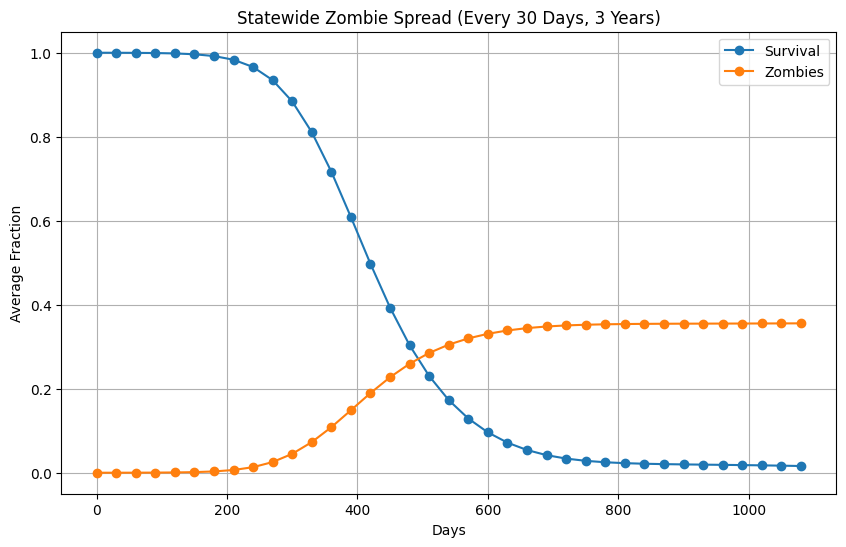


Zombie fraction by county (every 30 days):


,day_0,day_30,day_60,day_90,day_120,day_150,day_180,day_210,day_240,day_270,...,day_810,day_840,day_870,day_900,day_930,day_960,day_990,day_1020,day_1050,day_1080
county_key,,,,,,,,,,,,,,,,,,,,,
alamance,0.000006,0.000011,0.000022,0.000042,0.000083,0.000162,0.000317,0.000621,0.001212,0.002365,...,0.350548,0.350689,0.350762,0.350799,0.350818,0.350828,0.350833,0.350835,0.350836,0.350837
alexander,0.000027,0.000057,0.000116,0.000240,0.000493,0.001014,0.002082,0.004262,0.008671,0.017410,...,0.369416,0.369425,0.369429,0.369431,0.369432,0.369432,0.369433,0.369433,0.369433,0.369433
alleghany,0.000089,0.000176,0.000348,0.000685,0.001346,0.002645,0.005174,0.010059,0.019293,0.036138,...,0.353527,0.353534,0.353538,0.353540,0.353541,0.353542,0.353542,0.353542,0.353542,0.353542
anson,0.000045,0.000098,0.000212,0.000462,0.001005,0.002179,0.004713,0.010107,0.021353,0.043657,...,0.388795,0.388797,0.388798,0.388798,0.388798,0.388798,0.388798,0.388798,0.388798,0.388798
ashe,0.000037,0.000073,0.000144,0.000283,0.000556,0.001094,0.002144,0.004199,0.008166,0.015730,...,0.352949,0.352967,0.352977,0.352982,0.352984,0.352986,0.352986,0.352987,0.352987,0.352987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wayne,0.000008,0.000017,0.000036,0.000075,0.000155,0.000322,0.000666,0.001377,0.002842,0.005840,...,0.371605,0.371629,0.371641,0.371646,0.371649,0.371651,0.371651,0.371651,0.371652,0.371652
wilkes,0.000015,0.000030,0.000060,0.000119,0.000236,0.000469,0.000930,0.001845,0.003645,0.007174,...,0.356380,0.356417,0.356436,0.356445,0.356450,0.356452,0.356453,0.356454,0.356454,0.356455
wilson,0.000013,0.000027,0.000056,0.000119,0.000251,0.000530,0.001119,0.002356,0.004946,0.010293,...,0.378520,0.378530,0.378535,0.378537,0.378539,0.378539,0.378539,0.378539,0.378539,0.378539



Top 10 counties (best survival at 1080 days):


,county_key,survival_fraction,zombies,zombie_fraction
3403,wake,0.951650,9227.532379,0.007829
2219,mecklenburg,0.645615,81772.397487,0.070818
406,buncombe,0.001581,76159.494661,0.277590
3514,watauga,0.000260,15464.203884,0.280540
2515,orange,0.000242,43977.229245,0.293812
1516,guilford,0.000185,171275.513160,0.312581
3329,union,0.000119,77459.567359,0.308656
1183,durham,0.000115,103822.476714,0.312386
480,cabarrus,0.000095,73335.209453,0.310567
1664,henderson,0.000074,36185.062089,0.305400



Bottom 10 counties (worst survival at 1080 days):


,county_key,survival_fraction,zombies,zombie_fraction
3477,washington,5.620579e-11,4634.285714,0.428624
1923,jones,9.100054e-11,3924.058031,0.421851
3292,tyrrell,3.039546e-10,1374.543879,0.401561
3440,warren,5.967397e-10,7692.290695,0.409273
2182,martin,6.818291e-10,8859.216500,0.409315
1775,hyde,9.807371e-10,1798.588380,0.391679
2663,perquimans,1.339904e-09,5276.227552,0.398386
1368,gates,1.397743e-09,4106.278344,0.395748
1220,edgecombe,1.421213e-09,19980.839097,0.409981
2441,northampton,1.443807e-09,6772.187361,0.399987


In [ ]:
# =========================================================
# EXTENDED OUTBREAK ANALYSIS (1080 DAYS, EVERY 30 DAYS)
# =========================================================

extended_days = 1080
interval = 30

extended_rows = []

for _, row in model_df.iterrows():

    if pd.isna(row["population"]) or pd.isna(row["beta"]) or pd.isna(row["kappa"]):
        continue

    sol = simulate_county(
        population=row["population"],
        beta=row["beta"],
        kappa=row["kappa"],
        z0=1,              # use same z0 you used previously
        days=extended_days
    )

    if sol is None or not sol.success:
        continue

    S = sol.y[0]
    Z = sol.y[1]
    R = sol.y[2]
    t = sol.t
    N = row["population"]

    # Extract every 30 days
    for day in range(0, extended_days + 1, interval):
        idx = (np.abs(t - day)).argmin()

        extended_rows.append({
            "county_key": row["county_key"],
            "region": row["region"],
            "day": day,
            "survivability_index": row["survivability_index"],
            "survival_fraction": S[idx] / N,
            "zombies": Z[idx],
            "zombie_fraction": Z[idx] / N
        })

extended_df = pd.DataFrame(extended_rows)

# -----------------------------
# 1. STATEWIDE SUMMARY
# -----------------------------
statewide_30day = (
    extended_df.groupby("day")[["survival_fraction", "zombie_fraction"]]
    .mean()
    .reset_index()
)

print("Statewide averages every 30 days:")
display(statewide_30day)


# -----------------------------
# 2. PLOT OVER 3 YEARS
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(statewide_30day["day"], statewide_30day["survival_fraction"], marker='o', label="Survival")
plt.plot(statewide_30day["day"], statewide_30day["zombie_fraction"], marker='o', label="Zombies")

plt.xlabel("Days")
plt.ylabel("Average Fraction")
plt.title("Statewide Zombie Spread (Every 30 Days, 3 Years)")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------
# 3. COUNTY CHECKPOINT TABLE
# -----------------------------
county_30day_table = extended_df.pivot(
    index="county_key",
    columns="day",
    values="zombie_fraction"
)

county_30day_table.columns = [f"day_{int(c)}" for c in county_30day_table.columns]

print("\nZombie fraction by county (every 30 days):")
display(county_30day_table)


# -----------------------------
# 4. TOP / BOTTOM COUNTIES AT END (DAY 1080)
# -----------------------------
final_1080 = extended_df[extended_df["day"] == 1080]

print("\nTop 10 counties (best survival at 1080 days):")
display(
    final_1080.sort_values("survival_fraction", ascending=False)[
        ["county_key", "survival_fraction", "zombies", "zombie_fraction"]
    ].head(10)
)

print("\nBottom 10 counties (worst survival at 1080 days):")
display(
    final_1080.sort_values("survival_fraction", ascending=True)[
        ["county_key", "survival_fraction", "zombies", "zombie_fraction"]
    ].head(10)
)


# -----------------------------
# 5. OPTIONAL: ONE COUNTY CURVE

# change example_county to any county in your dataset to see its 3-year curve

# -----------------------------
# example_county = extended_df["county_key"].iloc[0]
# example_data = extended_df[extended_df["county_key"] == example_county]

# plt.figure(figsize=(10, 6))
# plt.plot(example_data["day"], example_data["zombie_fraction"], marker='o')

# plt.title(f"Zombie Growth Over Time: {example_county}")
# plt.xlabel("Days")
# plt.ylabel("Zombie Fraction")
# plt.grid(True)
# plt.show()

In [ ]:
# =========================================================
# PLOTLY COUNTY MAPS FOR NORTH CAROLINA
# Add this AFTER the cell where model_df is created
# =========================================================

import requests
import plotly.express as px


def polygon_centroid(coords):
    pts = np.array(coords)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.nan, np.nan
    lon = pts[:, 0].mean()
    lat = pts[:, 1].mean()
    return lat, lon


def feature_centroid(feature):
    geom = feature["geometry"]
    gtype = geom["type"]
    coords = geom["coordinates"]

    if gtype == "Polygon":
        return polygon_centroid(coords[0])

    if gtype == "MultiPolygon":
        largest_ring = max((poly[0] for poly in coords), key=len, default=None)
        if largest_ring is not None:
            return polygon_centroid(largest_ring)

    return np.nan, np.nan


def build_county_centroids(geojson):
    centroid_rows = []

    for feature in geojson["features"]:
        fips = str(feature["id"]).zfill(5)
        lat, lon = feature_centroid(feature)
        centroid_rows.append({
            "fips": fips,
            "lat": lat,
            "lon": lon
        })

    return pd.DataFrame(centroid_rows)


# -----------------------------
# 1. Reuse FIPS already added to model_df
# -----------------------------
map_df = model_df.copy()
map_df["county_key"] = map_df["county_key"].astype(str).str.strip().str.lower()
map_df = map_df.dropna(subset=["fips"]).copy()
map_df["fips"] = map_df["fips"].astype(str).str.zfill(5)

missing_fips = model_df[model_df["fips"].isna()]["county_key"].unique().tolist()
if missing_fips:
    print("These counties did not match the FIPS lookup:")
    print(missing_fips)

# -----------------------------
# 2. Load shared map geometry
# -----------------------------
geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties_geojson = requests.get(geojson_url).json()
centroid_df = build_county_centroids(counties_geojson)

# -----------------------------
# 3. Static choropleth:
#    survivability index
# -----------------------------
fig_survivability = px.choropleth(
    map_df,
    geojson=counties_geojson,
    locations="fips",
    color="survivability_index",
    scope="usa",
    featureidkey="id",
    hover_name="county_key",
    hover_data={
        "fips": True,
        "beta": ":.4f",
        "kappa": ":.4f",
        "growth_rate": ":.4f",
        "survivability_index": ":.3f"
    },
    color_continuous_scale="Viridis",
    title="North Carolina County Survivability Index"
)

fig_survivability.update_geos(
    fitbounds="locations",
    visible=False
)

fig_survivability.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig_survivability.show()

# -----------------------------
# 4. Static choropleth:
#    zombie growth rate
# -----------------------------
fig_growth = px.choropleth(
    map_df,
    geojson=counties_geojson,
    locations="fips",
    color="growth_rate",
    scope="usa",
    featureidkey="id",
    hover_name="county_key",
    hover_data={
        "fips": True,
        "beta": ":.4f",
        "kappa": ":.4f",
        "growth_rate": ":.4f",
        "survivability_index": ":.3f"
    },
    color_continuous_scale="RdYlGn_r",
    title="North Carolina County Zombie Growth Rate"
)

fig_growth.update_geos(
    fitbounds="locations",
    visible=False
)

fig_growth.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig_growth.show()

In [ ]:
# =========================================================
# ANIMATED COUNTY CHOROPLETH FOR OUTBREAK OVER TIME
# Add this AFTER extended_df is created
# =========================================================

animated_df = extended_df.copy()
animated_df["county_key"] = animated_df["county_key"].astype(str).str.strip().str.lower()
animated_df = animated_df.merge(
    model_df[["county_key", "fips"]].drop_duplicates(),
    on="county_key",
    how="left"
)
animated_df = animated_df.dropna(subset=["fips"]).copy()
animated_df["fips"] = animated_df["fips"].astype(str).str.zfill(5)

fig_zombies = px.choropleth(
    animated_df,
    geojson=counties_geojson,
    locations="fips",
    color="zombie_fraction",
    animation_frame="day",
    scope="usa",
    featureidkey="id",
    hover_name="county_key",
    hover_data={
        "survivability_index": ":.3f",
        "zombie_fraction": ":.3f",
        "survival_fraction": ":.3f",
        "day": True
    },
    color_continuous_scale="Reds",
    range_color=(0, animated_df["zombie_fraction"].max()),
    title="North Carolina Zombie Fraction Over Time"
)

fig_zombies.update_geos(
    fitbounds="locations",
    visible=False
)

fig_zombies.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig_zombies.show()

In [ ]:
# =========================================================
# ANIMATED COUNTY CHOROPLETH FOR OUTBREAK OVER TIME
# Add this AFTER extended_df is created
# =========================================================

animated_df = extended_df.copy()
animated_df["county_key"] = animated_df["county_key"].astype(str).str.strip().str.lower()
animated_df = animated_df.merge(
    model_df[["county_key", "fips"]].drop_duplicates(),
    on="county_key",
    how="left"
)
animated_df = animated_df.dropna(subset=["fips"]).copy()
animated_df["fips"] = animated_df["fips"].astype(str).str.zfill(5)

fig_zombies = px.choropleth(
    animated_df,
    geojson=counties_geojson,
    locations="fips",
    color="survival_fraction",
    animation_frame="day",
    scope="usa",
    featureidkey="id",
    hover_name="county_key",
    hover_data={
        "survivability_index": ":.3f",
        "zombie_fraction": ":.3f",
        "survival_fraction": ":.3f",
        "day": True
    },
    color_continuous_scale="Greens",
    range_color=(0, 1),
    title="North Carolina Survival Fraction Over Time"
)

fig_zombies.update_geos(
    fitbounds="locations",
    visible=False
)

fig_zombies.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig_zombies.show()

Buffered data was truncated after reaching the output size limit.

In [ ]:
import requests
import numpy as np
import pandas as pd
import plotly.express as px

# -------------------------------------------------
# 1. Start from your existing extended_df
# -------------------------------------------------
bubble_df = extended_df.copy()
bubble_df["county_key"] = bubble_df["county_key"].astype(str).str.strip().str.lower()

# -------------------------------------------------
# 2. Bring in FIPS from model_df
# -------------------------------------------------
county_fips = model_df[["county_key", "fips"]].drop_duplicates().copy()
county_fips["county_key"] = county_fips["county_key"].astype(str).str.strip().str.lower()
county_fips = county_fips.dropna(subset=["fips"])
county_fips["fips"] = county_fips["fips"].astype(str).str.zfill(5)

bubble_df = bubble_df.merge(
    county_fips,
    on="county_key",
    how="left"
)

missing_fips = bubble_df[bubble_df["fips"].isna()]["county_key"].drop_duplicates().tolist()
if missing_fips:
    print("These counties are missing FIPS codes:")
    print(missing_fips)

bubble_df = bubble_df.dropna(subset=["fips"]).copy()
bubble_df["fips"] = bubble_df["fips"].astype(str).str.zfill(5)

# -------------------------------------------------
# 3. Load county GeoJSON
# -------------------------------------------------
counties_geojson = requests.get(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
).json()

# -------------------------------------------------
# 4. Helper function to compute a simple centroid
#    from polygon coordinates
# -------------------------------------------------
def polygon_centroid(coords):
    pts = np.array(coords)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.nan, np.nan
    lon = pts[:, 0].mean()
    lat = pts[:, 1].mean()
    return lat, lon

def feature_centroid(feature):
    geom = feature["geometry"]
    gtype = geom["type"]
    coords = geom["coordinates"]

    if gtype == "Polygon":
        # use outer ring only
        return polygon_centroid(coords[0])

    elif gtype == "MultiPolygon":
        # choose the largest outer ring by number of points
        largest_ring = None
        largest_n = -1

        for poly in coords:
            outer = poly[0]
            if len(outer) > largest_n:
                largest_ring = outer
                largest_n = len(outer)

        return polygon_centroid(largest_ring)

    return np.nan, np.nan

# -------------------------------------------------
# 5. Build centroid table from GeoJSON
# -------------------------------------------------
centroid_rows = []

for feature in counties_geojson["features"]:
    fips = str(feature["id"]).zfill(5)
    lat, lon = feature_centroid(feature)
    centroid_rows.append({
        "fips": fips,
        "lat": lat,
        "lon": lon
    })

centroid_df = pd.DataFrame(centroid_rows)

# -------------------------------------------------
# 6. Merge centroids into outbreak data
# -------------------------------------------------
bubble_df = bubble_df.merge(
    centroid_df,
    on="fips",
    how="left"
)

# Optional safety check
missing_centroids = bubble_df[bubble_df["lat"].isna() | bubble_df["lon"].isna()]
if len(missing_centroids) > 0:
    print("Missing centroid rows:")
    display(missing_centroids[["county_key", "fips"]].drop_duplicates())

# -------------------------------------------------
# 7. Create a display size column so small outbreaks
#    are still visible
# -------------------------------------------------
bubble_df["bubble_size"] = bubble_df["zombie_fraction"] * 250

# optional minimum size so day 0 still shows
bubble_df["bubble_size"] = bubble_df["bubble_size"].clip(lower=3)

# -------------------------------------------------
# 8. Animated bubble map
# -------------------------------------------------
fig_bubble = px.scatter_map(
    bubble_df,
    lat="lat",
    lon="lon",
    size="bubble_size",
    color="zombie_fraction",
    animation_frame="day",
    hover_name="county_key",
    hover_data={
        "day": True,
        "zombie_fraction": ":.3f",
        "survival_fraction": ":.3f",
        "fips": True,
        "lat": False,
        "lon": False,
        "bubble_size": False
    },
    color_continuous_scale="Reds",
    range_color=(0, bubble_df["zombie_fraction"].max()),
    zoom=6,
    center={"lat": 35.5, "lon": -79.0},
    size_max=45,
    title="Animated Zombie Outbreak Over Time by County"
)

fig_bubble.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig_bubble.show()

In [ ]:
# =========================================================
# SAVE ANIMATED MAP FOR POWERPOINT
# Paste this in a new cell below your animation cell
# =========================================================

from pathlib import Path
from IPython.display import display, FileLink

# -----------------------------------
# 1. Detect your latest figure
# -----------------------------------
fig_to_save = None
figure_name = None
for name in ["fig_bubble", "fig_zombies", "fig_growth", "fig_survivability"]:
    if name in globals():
        fig_to_save = globals()[name]
        figure_name = name
        break

if fig_to_save is None:
    raise NameError("No Plotly figure found. Run your map cell first.")

# -----------------------------------
# 2. Save as standalone HTML
# (interactive, works offline, no Kaleido needed)
# -----------------------------------
out_dir = Path.cwd() / "ppt_exports"
out_dir.mkdir(exist_ok=True)

html_path = out_dir / "zombie_outbreak_animation.html"
fig_to_save.write_html(
    str(html_path),
    include_plotlyjs=True,
    full_html=True,
    auto_play=False       # prevents autoplay so you control it in browser
)

print(f"Saved: {html_path}")
print("\nFor PowerPoint:")
print("  1. Open the HTML file in Chrome/Edge")
print("  2. Use the play button to animate, then screenshot each frame")
print("  3. OR insert the HTML file as a web object if using PowerPoint 365")
display(FileLink(str(html_path)))

Saved: /content/ppt_exports/zombie_outbreak_animation.html

For PowerPoint:
  1. Open the HTML file in Chrome/Edge
  2. Use the play button to animate, then screenshot each frame
  3. OR insert the HTML file as a web object if using PowerPoint 365


/content/ppt_exports/zombie_outbreak_animation.html

# Additional Visualizations
### Research Questions 3 & 4 — Where are the most/least affected areas? How do human factors modify survival odds?

In [ ]:
# =========================================================
# VISUAL 1 — HSI vs. SURVIVAL FRACTION SCATTER
# Does a higher survivability index actually predict better outcomes?
# =========================================================

import plotly.express as px
import pandas as pd

# Build a clean analysis frame from the 1080-day summary
_scatter_1080 = extended_df[extended_df["day"] == 1080][["county_key", "survival_fraction", "zombie_fraction"]].copy()
_scatter_1080["county_key"] = _scatter_1080["county_key"].str.strip().str.lower()
_scatter_1080["survival_pct"] = (_scatter_1080["survival_fraction"] * 100).round(2)

_meta = model_df[["county_key", "survivability_index", "region", "population",
                   "geo_score", "health_score", "edu_score",
                   "mobility_score", "social_score", "prep_score"]].copy()
_meta["county_key"] = _meta["county_key"].str.strip().str.lower()

scatter_df = _scatter_1080.merge(_meta, on="county_key", how="inner")
scatter_df["county_display"] = scatter_df["county_key"].str.title() + " County"

fig_scatter = px.scatter(
    scatter_df,
    x="survivability_index",
    y="survival_pct",
    color="region",
    size="population",
    hover_name="county_display",
    hover_data={
        "survivability_index": ":.3f",
        "survival_pct": ":.2f",
        "region": True,
        "population": ":,.0f",
    },
    trendline="ols",
    trendline_scope="overall",
    trendline_color_override="black",
    labels={
        "survivability_index": "Human Survival Index (HSI)",
        "survival_pct": "Survival % at Day 1080",
        "region": "Region",
        "population": "Population",
    },
    title="HSI vs. Survival Rate (Day 1080) — Does the Index Predict Outcomes?",
    template="plotly_white",
)
fig_scatter.update_traces(marker=dict(opacity=0.75, line=dict(width=0.5, color="white")))
fig_scatter.update_layout(
    height=550,
    legend_title_text="Region",
    font=dict(size=13),
)
fig_scatter.show()

# Pearson correlation
corr = scatter_df[["survivability_index", "survival_pct"]].corr().iloc[0, 1]
print(f"Pearson r (HSI vs Survival %): {corr:.4f}")


Pearson r (HSI vs Survival %): 0.5801


In [ ]:
# =========================================================
# VISUAL 2 — TOP 10 / BOTTOM 10 COUNTY RANKINGS (Day 1080)
# =========================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

_rank_df = scatter_df.sort_values("survival_pct", ascending=False).copy()
top10    = _rank_df.head(10)
bottom10 = _rank_df.tail(10).sort_values("survival_pct", ascending=True)

region_palette = {"mountain": "#4e8ecf", "coastal": "#f5a623", "central": "#7ed321"}

fig_rank = make_subplots(
    rows=1, cols=2,
    subplot_titles=["Top 10 — Highest Survival % (Day 1080)",
                    "Bottom 10 — Lowest Survival % (Day 1080)"],
    horizontal_spacing=0.12,
)

# Top 10
fig_rank.add_trace(
    go.Bar(
        x=top10["survival_pct"],
        y=top10["county_display"],
        orientation="h",
        marker_color=[region_palette.get(r, "#999") for r in top10["region"]],
        text=top10["survival_pct"].apply(lambda v: f"{v:.2f}%"),
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Survival: %{x:.2f}%<extra></extra>",
        name="Safest",
    ),
    row=1, col=1,
)

# Bottom 10
fig_rank.add_trace(
    go.Bar(
        x=bottom10["survival_pct"],
        y=bottom10["county_display"],
        orientation="h",
        marker_color=[region_palette.get(r, "#999") for r in bottom10["region"]],
        text=bottom10["survival_pct"].apply(lambda v: f"{v:.2f}%"),
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>Survival: %{x:.2f}%<extra></extra>",
        name="Most Dangerous",
    ),
    row=1, col=2,
)

fig_rank.update_xaxes(title_text="Survival %", row=1, col=1)
fig_rank.update_xaxes(title_text="Survival %", row=1, col=2)
fig_rank.update_layout(
    height=450,
    showlegend=False,
    template="plotly_white",
    font=dict(size=12),
    title_text="NC County Survival Rankings at Day 1080",
    title_font_size=16,
)
fig_rank.show()

print("\nTop 10 Safest Counties:")
print(top10[["county_display", "region", "survivability_index", "survival_pct"]].to_string(index=False))
print("\nBottom 10 Most Dangerous Counties:")
print(bottom10[["county_display", "region", "survivability_index", "survival_pct"]].to_string(index=False))



Top 10 Safest Counties:
    county_display   region  survivability_index  survival_pct
       Wake County  central             1.000000         95.16
Mecklenburg County  central             0.889396         64.56
   Buncombe County mountain             0.633510          0.16
    Watauga County mountain             0.624371          0.03
   Guilford County  central             0.506298          0.02
     Orange County  central             0.576415          0.02
      Union County  central             0.521293          0.01
  Henderson County mountain             0.533624          0.01
     Durham County  central             0.507128          0.01
   Cabarrus County  central             0.514075          0.01

Bottom 10 Most Dangerous Counties:
   county_display   region  survivability_index  survival_pct
   Tyrrell County  coastal             0.131459           0.0
     Surry County  central             0.236874           0.0
     Vance County  central             0.216361           0.

In [ ]:
# =========================================================
# VISUAL 3 — HSI COMPONENT RADAR CHART
# Top 5 safest vs Bottom 5 most dangerous counties
# Shows *why* they scored the way they did.
# =========================================================

import plotly.graph_objects as go
import numpy as np

COMPONENTS = ["geo_score", "health_score", "edu_score",
              "mobility_score", "social_score", "prep_score"]
LABELS = ["Geo/Weather (EG)", "Health & Fitness (HP)", "Education (EA)",
          "Mobility & Escape (ME)", "Social & Community (SC)", "Infrastructure (IP)"]
WEIGHTS = [0.15, 0.20, 0.10, 0.15, 0.25, 0.15]

_radar_df = scatter_df.sort_values("survival_pct", ascending=False).copy()
top5    = _radar_df.head(5)
bottom5 = _radar_df.tail(5)

fig_radar = go.Figure()

# Individual top-5 counties (light blue traces)
for _, row in top5.iterrows():
    vals = [row[c] for c in COMPONENTS]
    vals_closed = vals + [vals[0]]
    labs_closed = LABELS + [LABELS[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals_closed, theta=labs_closed,
        mode="lines",
        line=dict(color="rgba(78,142,207,0.4)", width=1),
        showlegend=False,
        hovertemplate=row["county_display"] + "<br>%{theta}: %{r:.3f}<extra></extra>",
    ))

# Individual bottom-5 counties (light red traces)
for _, row in bottom5.iterrows():
    vals = [row[c] for c in COMPONENTS]
    vals_closed = vals + [vals[0]]
    labs_closed = LABELS + [LABELS[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals_closed, theta=labs_closed,
        mode="lines",
        line=dict(color="rgba(220,80,60,0.4)", width=1),
        showlegend=False,
        hovertemplate=row["county_display"] + "<br>%{theta}: %{r:.3f}<extra></extra>",
    ))

# Bold average line for top 5
top5_avg = [top5[c].mean() for c in COMPONENTS]
top5_avg_closed = top5_avg + [top5_avg[0]]
fig_radar.add_trace(go.Scatterpolar(
    r=top5_avg_closed, theta=labs_closed,
    mode="lines+markers",
    line=dict(color="#1a5fa8", width=3),
    marker=dict(size=6),
    fill="toself",
    fillcolor="rgba(78,142,207,0.15)",
    name="Top 5 avg (safest)",
    hovertemplate="Top 5 avg<br>%{theta}: %{r:.3f}<extra></extra>",
))

# Bold average line for bottom 5
bot5_avg = [bottom5[c].mean() for c in COMPONENTS]
bot5_avg_closed = bot5_avg + [bot5_avg[0]]
fig_radar.add_trace(go.Scatterpolar(
    r=bot5_avg_closed, theta=labs_closed,
    mode="lines+markers",
    line=dict(color="#c0392b", width=3),
    marker=dict(size=6),
    fill="toself",
    fillcolor="rgba(220,80,60,0.15)",
    name="Bottom 5 avg (most dangerous)",
    hovertemplate="Bottom 5 avg<br>%{theta}: %{r:.3f}<extra></extra>",
))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(
        text="HSI Component Breakdown — Safest vs Most Dangerous Counties",
        font=dict(size=16),
    ),
    legend=dict(x=0.85, y=1.1),
    template="plotly_white",
    height=550,
)
fig_radar.show()


In [ ]:
# =========================================================
# VISUAL 4 — INDIVIDUAL COUNTY TIME SERIES
# Zombie growth curves for representative counties
# (best, worst, median, and one per region)
# =========================================================

import plotly.graph_objects as go

# Pick representative counties
_ts_df = scatter_df.sort_values("survival_pct", ascending=False).copy()
_ts_df = _ts_df.reset_index(drop=True)

best_county    = _ts_df.iloc[0]["county_key"]
worst_county   = _ts_df.iloc[-1]["county_key"]
median_county  = _ts_df.iloc[len(_ts_df) // 2]["county_key"]
mountain_rep   = _ts_df[_ts_df["region"] == "mountain"].iloc[0]["county_key"]
coastal_rep    = _ts_df[_ts_df["region"] == "coastal"].iloc[0]["county_key"]
central_rep    = _ts_df[_ts_df["region"] == "central"].iloc[0]["county_key"]

highlight_counties = {
    best_county:   dict(color="#1a5fa8", label="Best"),
    worst_county:  dict(color="#c0392b", label="Worst"),
    median_county: dict(color="#7f8c8d", label="Median"),
    mountain_rep:  dict(color="#27ae60", label="Mountain rep"),
    coastal_rep:   dict(color="#f39c12", label="Coastal rep"),
    central_rep:   dict(color="#8e44ad", label="Central rep"),
}

# Pull 1080-day time series (every 30 days)
ts_source = extended_df.copy()
ts_source["county_key"] = ts_source["county_key"].str.strip().str.lower()

fig_ts = go.Figure()

for ck, style in highlight_counties.items():
    county_ts = ts_source[ts_source["county_key"] == ck].sort_values("day")
    if county_ts.empty:
        continue
    display = ck.title() + " County"
    fig_ts.add_trace(go.Scatter(
        x=county_ts["day"],
        y=(county_ts["zombie_fraction"] * 100).round(2),
        mode="lines+markers",
        name=f"{display} ({style['label']})",
        line=dict(color=style["color"], width=2.5),
        marker=dict(size=5),
        hovertemplate=f"<b>{display}</b><br>Day %{{x}}<br>Zombie %: %{{y:.2f}}%<extra></extra>",
    ))

fig_ts.update_layout(
    title="Zombie Growth Over 1080 Days — Representative Counties",
    xaxis_title="Day",
    yaxis_title="Zombie % of Population",
    template="plotly_white",
    height=500,
    legend=dict(x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.85)"),
    font=dict(size=13),
)
fig_ts.show()


In [ ]:
# =========================================================
# VISUAL 5 — REGION-LEVEL SURVIVAL DISTRIBUTION (Violin + Box)
# Urban / Suburban / Rural survival outcomes at Day 1080
# =========================================================

import plotly.graph_objects as go

region_palette = {"mountain": "#4e8ecf", "coastal": "#f5a623", "central": "#7ed321"}

fig_violin = go.Figure()

for region, color in region_palette.items():
    region_data = scatter_df[scatter_df["region"] == region]["survival_pct"]
    fig_violin.add_trace(go.Violin(
        y=region_data,
        name=region.title(),
        box_visible=True,
        meanline_visible=True,
        points="all",
        jitter=0.3,
        pointpos=-1.6,
        marker=dict(size=5, opacity=0.6),
        line_color=color,
        fillcolor=color.replace(")", ", 0.25)").replace("rgb", "rgba") if "rgb" in color else color,
        opacity=0.8,
        hovertemplate="<b>" + region.title() + "</b><br>Survival %: %{y:.2f}%<extra></extra>",
    ))

fig_violin.update_layout(
    title="Survival % Distribution by NC Region at Day 1080",
    yaxis_title="Survival % at Day 1080",
    template="plotly_white",
    height=500,
    showlegend=True,
    font=dict(size=13),
    violingap=0.15,
)
fig_violin.show()

# Summary stats by region
print("\nRegion-level survival stats (Day 1080):")
print(scatter_df.groupby("region")["survival_pct"].agg(["mean", "median", "min", "max", "count"]).round(2))



Region-level survival stats (Day 1080):
          mean  median  min    max  count
region                                   
central   3.72     0.0  0.0  95.16     43
coastal   0.00     0.0  0.0   0.00     36
mountain  0.01     0.0  0.0   0.16     21


In [ ]:
# =========================================================
# VISUAL 6 — WEIGHTED HSI COMPONENT CONTRIBUTION (Stacked Bar)
# Shows the weighted contribution of each HSI component
# for every county, sorted by overall survivability index
# =========================================================

import plotly.graph_objects as go

COMPONENTS  = ["social_score", "health_score", "mobility_score",
               "geo_score", "prep_score", "edu_score"]
LABELS      = ["Social & Community (SC, 25%)", "Health & Fitness (HP, 20%)",
               "Mobility & Escape (ME, 15%)", "Geo/Weather (EG, 15%)",
               "Infrastructure (IP, 15%)", "Education (EA, 10%)"]
WEIGHTS     = [0.25, 0.20, 0.15, 0.15, 0.15, 0.10]
COLORS      = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c"]

_comp_df = scatter_df.sort_values("survivability_index", ascending=True).copy()
_comp_df["county_display"] = _comp_df["county_key"].str.title() + " County"

fig_stack = go.Figure()

for comp, label, weight, color in zip(COMPONENTS, LABELS, WEIGHTS, COLORS):
    weighted_vals = (_comp_df[comp] * weight).round(4)
    fig_stack.add_trace(go.Bar(
        name=label,
        x=_comp_df["county_display"],
        y=weighted_vals,
        marker_color=color,
        hovertemplate="<b>%{x}</b><br>" + label + "<br>Weighted score: %{y:.4f}<extra></extra>",
    ))

# Overlay the survivability index as a line
fig_stack.add_trace(go.Scatter(
    x=_comp_df["county_display"],
    y=_comp_df["survivability_index"],
    mode="lines",
    name="HSI (composite)",
    line=dict(color="black", width=2, dash="dot"),
    hovertemplate="<b>%{x}</b><br>HSI: %{y:.3f}<extra></extra>",
    yaxis="y2",
))

fig_stack.update_layout(
    barmode="stack",
    title="Weighted HSI Component Breakdown per County (sorted by HSI, low → high)",
    xaxis=dict(title="County", tickangle=45, tickfont=dict(size=8)),
    yaxis=dict(title="Weighted Component Score"),
    yaxis2=dict(
        title="HSI (composite)",
        overlaying="y",
        side="right",
        range=[0, 1],
        showgrid=False,
    ),
    legend=dict(x=1.05, y=1, bgcolor="rgba(255,255,255,0.85)"),
    template="plotly_white",
    height=580,
    font=dict(size=11),
)
fig_stack.show()
